In [1]:
import pandas as pd

df = pd.read_csv("week4_energy_emissions.csv")
df.head()

,Region,Energy_Type,CO2_Emissions
0,Asia,Solar,0.79
1,Asia,Solar,2.46
2,Asia,Solar,2.77
3,Asia,Solar,3.21
4,Asia,Solar,3.51


In [4]:
import math
from itertools import product

regions = df["Region"].unique()
types = df["Energy_Type"].unique()

# How many unique combinations?
print("Combinations (nCr):", math.comb(len(regions) + len(types), 2))

# How many region-energy pairs?
pairs = list(product(regions, types))
print("Region × Energy combinations:", len(pairs))

# Try This: what if we had 4 regions instead?
new_regions = ['Asia', 'Africa', 'Europe', 'South America']
new_pairs = list(product(new_regions, types))
print("Region x Energy combinations with 4 regions:", len(new_pairs))

Combinations (nCr): 15
Region × Energy combinations: 9
Region x Energy combinations with 4 regions: 12


In [6]:
df["Region_Energy"] = df["Region"] + "_" + df["Energy_Type"]
df["Energy_Region"] = df["Energy_Type"] + "_" + df["Region"]
df.head()

,Region,Energy_Type,CO2_Emissions,Region_Energy,Energy_Region
0,Asia,Solar,0.79,Asia_Solar,Solar_Asia
1,Asia,Solar,2.46,Asia_Solar,Solar_Asia
2,Asia,Solar,2.77,Asia_Solar,Solar_Asia
3,Asia,Solar,3.21,Asia_Solar,Solar_Asia
4,Asia,Solar,3.51,Asia_Solar,Solar_Asia


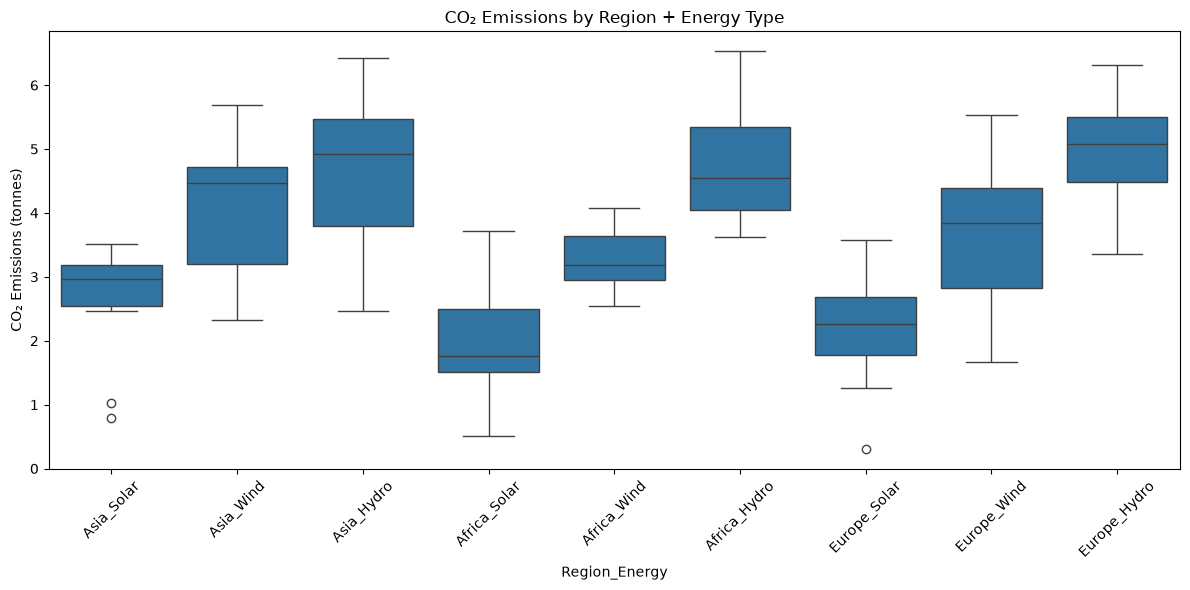

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region_Energy", y="CO2_Emissions")
plt.title("CO₂ Emissions by Region + Energy Type")
plt.xticks(rotation=45)
plt.ylabel("CO₂ Emissions (tonnes)")
plt.tight_layout()
plt.show()

In [9]:
# Try increasing emissions for 'Hydro'
df.loc[df["Energy_Type"] == "Hydro", "CO2_Emissions"] *= 1.2

In [ ]:
new_row = {"Region": "Asia", "Energy_Type": "Biomass", "CO2_Emissions": 4.2,
           "Region_Energy": "Asia_Biomass", "Energy_Region": "Biomass_Asia"}
df.loc[len(df)] = new_row
df.tail()

#After boosting hydro emissions by 20% the hydro boxes shift higher, 

,Region,Energy_Type,CO2_Emissions,Region_Energy,Energy_Region
86,Europe,Hydro,7.320,Europe_Hydro,Hydro_Europe
87,Europe,Hydro,6.000,Europe_Hydro,Hydro_Europe
88,Europe,Hydro,7.572,Europe_Hydro,Hydro_Europe
89,Europe,Hydro,6.564,Europe_Hydro,Hydro_Europe
90,Asia,Biomass,4.200,Asia_Biomass,Biomass_Asia
